1. Kontrol Edilen Dizin: C:\Users\PC KULLANICISI
Dosya CWD'de bulundu: data_mp3.csv
Veriler yüklendi.
Veriler yüklendi. Satır x Sütun: (50, 2)


,Kafein miktar (mg),Duygu durumlar
0,74.0,Stressed
1,164.0,Neutral
2,88.0,Happy
3,121.0,Stressed
4,110.0,Happy



--- TEMEL İSTATİSTİKLER (sayısal sütunlar) ---
Sütun: Kafein miktar (mg)
  Mean  : 101.68
  Median: 92.5
  Std   : 45.28748982549019


--- TEMEL İSTATİSTİKLER (metinsel sütunlar) ---
Sütun: Duygu durumlar
  Unique Değer Sayısı: 3
  En Çok Tekrar Eden : Neutral
  Null Sayısı        : 0


--- EKSİK VERİ KONTROLÜ ---
Kafein miktar (mg)    0
Duygu durumlar        0
dtype: int64

--- KORELASYON MATRİSİ ---
                    Kafein miktar (mg)
Kafein miktar (mg)                 1.0


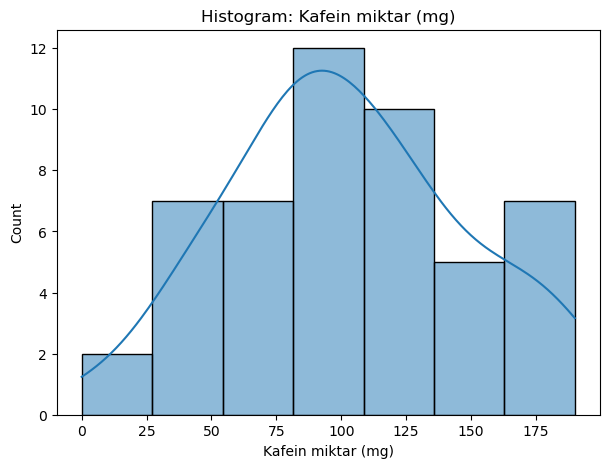

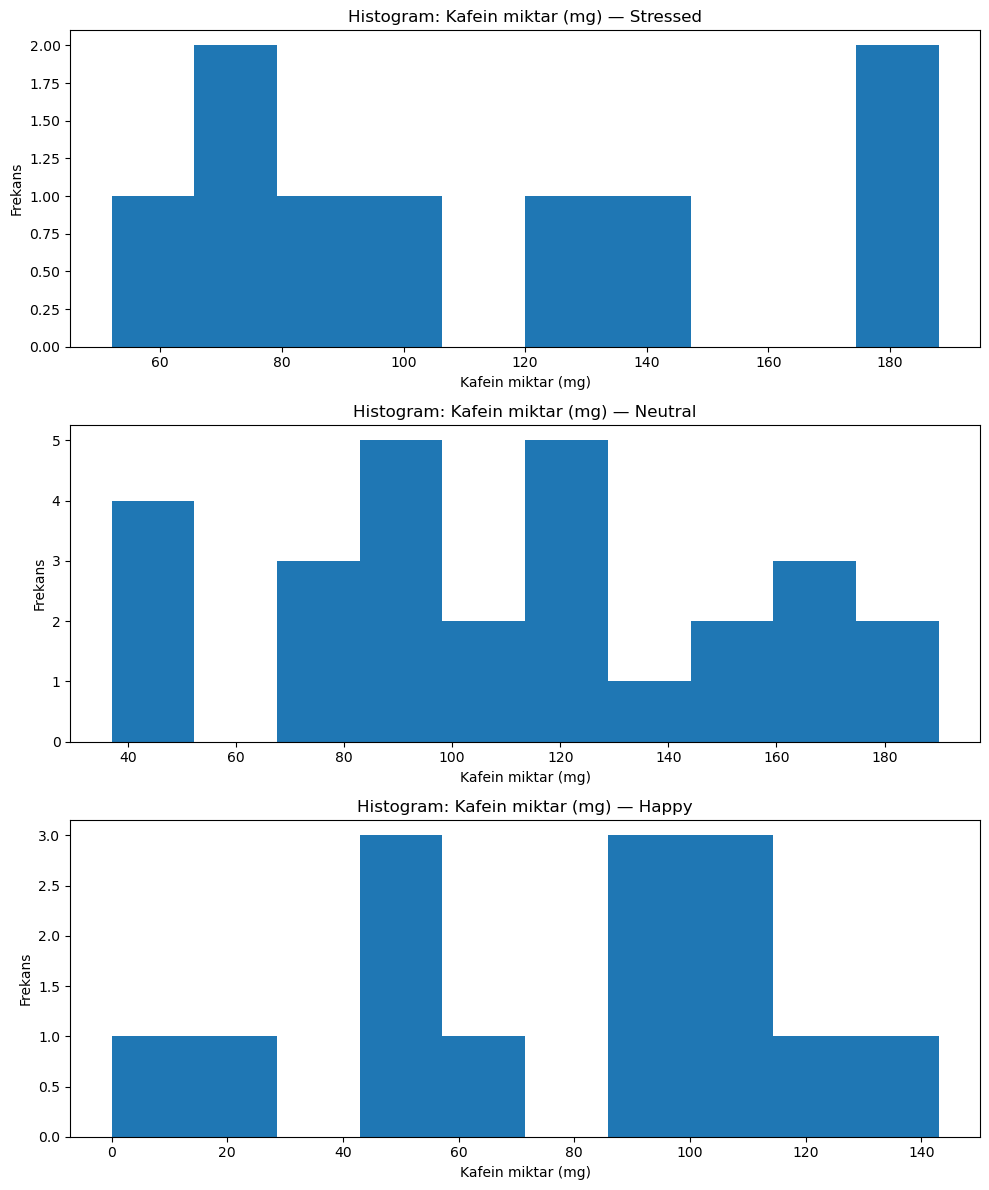

Stresli → Kafein tüketim miktarı yüksektir.
Nötr → Kafein tüketim miktarı dağınıktır, tepe noktası yoktur ve orta seviyelerde daha yoğundur.
Mutlu → Kafein tüketimi orta seviyelerdedir, uç değerler yoktur.


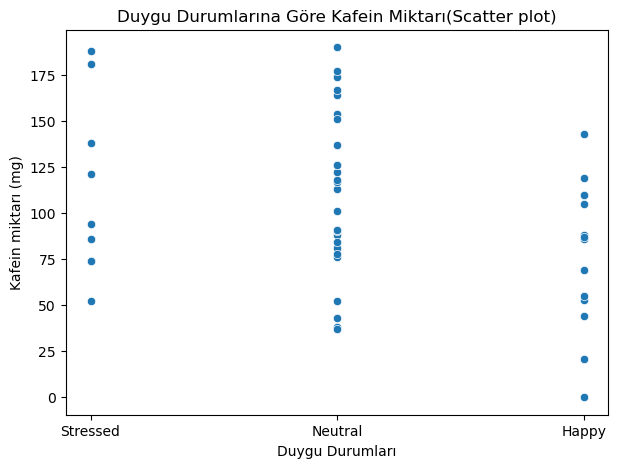

Nötr grubun diğer gruplara göre daha geniş bir miktar aralığına yayıldığı görülüyor.


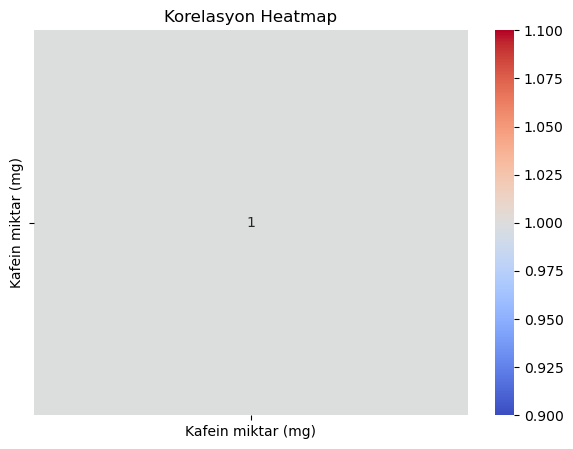

Veri setinde sadece tek bir sayısal sütun olduğundan heatmap hiçbir ilişki göstermez, sadece kafein miktarının kendisiyle olan korelasyonu yani 1'den oluşan tek bir kare şeklinde görünür.


<Figure size 800x600 with 0 Axes>

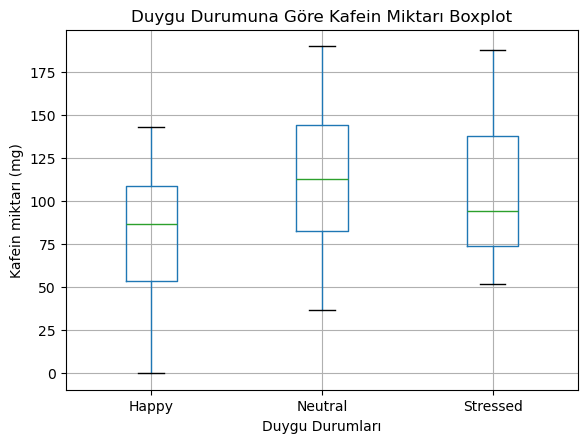

Mutlu Grupta
Medyan: Yaklaşık 85–90 mg
Dağılım: 0 mg’den yaklaşık 145 mg’ye kadar geniş bir aralık, orta seviyelerde daha yoğun.
Yorum: Mutlu kişilerde kafein tüketimi daha düşük ve daha geniş bir dağılıma sahip. Bazıları hiç tüketmezken bazıları orta düzeyde tüketiyor.

Nötr Grupta
Medyan: Yaklaşık 110–115 mg
Dağılım: Yaklaşık 40 mg’den 190 mg’ye kadar.
Yorum: Nötr durumda insanlar genel olarak daha fazla kafein tüketimi görülüyor. Bu durum “rutinde içilen kahve/çay” alışkanlığını yansıtıyor olabilir.

Stresli Grup
Medyan: Yaklaşık 95 mg
Dağılım: Yaklaşık 50 mg – 190 mg
Yorum: Stresli kişilerde kafein tüketimi artıyor, ancak bazı kişiler çok içerken bazıları sadece biraz artırıyor.


--- KISA ÖZET ---
1) Temel istatistikler hesaplandı.
2) Eksik veri kontrolü yapıldı.
3) Korelasyon matrisi, histogram, scatter plot,heatmap ve boxplot ile görselleştirmeler yapıldı.
4) Genel olarak stresli kişilerin daha yüksek kafein tükettiği, mutlu kişilerin ise daha orta düzeylerde tükettiği görülüyor

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Notebook'un çalıştığı varsayılan dizin.

print("1. Kontrol Edilen Dizin:", os.getcwd())



# MP4 klasörü içinde mi?

if os.path.exists('data_mp3.csv'):

    print("Dosya CWD'de bulundu: data_mp3.csv")

    yol = 'data_mp3.csv'

elif os.path.exists('MP4/data_mp3.csv'):

    print("Dosya CWD'nin bir üstündeki MP4 klasöründe bulundu: MP4/data_mp3.csv")

    yol = 'MP4/data_mp3.csv'

else:

    print("Dosya bulunamadı. Lütfen dosya adını/konumunu kontrol edin.")

    # Burada bir hata fırlatabiliriz veya programı durdurabiliriz.

    yol = None



if yol:

    # Veri yükleme

    data = pd.read_csv(yol, sep=";", encoding='utf-8-sig', encoding_errors='ignore')

    print("Veriler yüklendi.")

# 1) Veri yükleme
data = pd.read_csv('data_mp3.csv', sep=";", encoding='utf-8-sig', encoding_errors='ignore')
print("Veriler yüklendi. Satır x Sütun:", data.shape)
display(data.head())


# 2) Sütunları tipiyle ayır
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
object_cols = data.select_dtypes(include=['object']).columns

# 3) Temel istatistikler
print("\n--- TEMEL İSTATİSTİKLER (sayısal sütunlar) ---")
if len(numeric_cols) == 0:
    print("Veri setinde sayısal sütun bulunamadı.")
else:
    for col in numeric_cols:
        print(f"Sütun: {col}")
        print("  Mean  :", data[col].mean())
        print("  Median:", data[col].median())
        print("  Std   :", data[col].std())
        print("")

print("\n--- TEMEL İSTATİSTİKLER (metinsel sütunlar) ---")
if len(object_cols) == 0:
    print("Veri setinde metinsel sütun bulunamadı.")
else:
    for col in object_cols:
        print(f"Sütun: {col}")
        print("  Unique Değer Sayısı:", data[col].nunique())
        print("  En Çok Tekrar Eden :", data[col].mode()[0])
        print("  Null Sayısı        :", data[col].isnull().sum())
        print("")

# 4) Eksik veri kontrolü
print("\n--- EKSİK VERİ KONTROLÜ ---")
print(data.isnull().sum())

# 5) Korelasyon matrisi (sayısal sütunlar)
num_df = data[numeric_cols]
print("\n--- KORELASYON MATRİSİ ---")
if num_df.shape[1] >= 1:
    print(num_df.corr())
else:
    print("Veride sayısal sütun bulunmuyor; korelasyon matrisi oluşturulamadı.")

# Histogram
plt.figure(figsize=(7,5))
sns.histplot(data[numeric_cols[0]], kde=True)
plt.title("Histogram: " + numeric_cols[0])
plt.show()
# --- 2) Sayısal sütunu ve duygu durumunu bul ---
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
value_col = numeric_cols[0]   # ör: "Kafein miktarı (mg)"

# Duygu durumu sütunu
possible_emotion_cols = ['Duygu durumları', 'Duygu durumlar', 'Duygu durumu']
category_col = None

for col in data.columns:
    if col.strip() in possible_emotion_cols:
        category_col = col
        break

if category_col is None:
    # ikinci sütun duygu durumu olabilir
    category_col = data.columns[1]

# --- 3) Benzersiz duygu kategorilerini al ---
categories = data[category_col].dropna().unique()

# --- 4) Histogramları çiz ---
plt.figure(figsize=(10, 12))

for i, cat in enumerate(categories, 1):
    subset = data[data[category_col] == cat][value_col].dropna()

    
    
    plt.subplot(len(categories), 1, i)
    plt.hist(subset)  # renk verilmedi (kurala uygun)
    plt.title(f"Histogram: {value_col} — {cat}")
    plt.xlabel(value_col)
    plt.ylabel("Frekans")

plt.tight_layout()
plt.show()

print("Stresli → Kafein tüketim miktarı yüksektir.")
print("Nötr → Kafein tüketim miktarı dağınıktır, tepe noktası yoktur ve orta seviyelerde daha yoğundur.")
print("Mutlu → Kafein tüketimi orta seviyelerdedir, uç değerler yoktur.")

plt.figure(figsize=(7,5))
sns.scatterplot(x='Duygu durumlar', y='Kafein miktar (mg)', data=data)
plt.title("Duygu Durumlarına Göre Kafein Miktarı(Scatter plot)")
plt.xlabel("Duygu Durumları")
plt.ylabel("Kafein miktarı (mg)")
plt.show()
print("Nötr grubun diğer gruplara göre daha geniş bir miktar aralığına yayıldığı görülüyor.")
# Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Korelasyon Heatmap")
plt.show()
print("Veri setinde sadece tek bir sayısal sütun olduğundan heatmap hiçbir ilişki göstermez, sadece kafein miktarının kendisiyle olan korelasyonu yani 1'den oluşan tek bir kare şeklinde görünür.")

# Sayısal sütunu seç (ilk sütun kafein miktarı)
kafein = data.iloc[:, 0].dropna()

plt.figure(figsize=(8,6))
data.boxplot(column='Kafein miktar (mg)', by='Duygu durumlar')
plt.title("Duygu Durumuna Göre Kafein Miktarı Boxplot")
plt.suptitle("")  # otomatik başlığı kaldırmak için
plt.xlabel("Duygu Durumları")
plt.ylabel("Kafein miktarı (mg)")
plt.show()
print("Mutlu Grupta\nMedyan: Yaklaşık 85–90 mg\nDağılım: 0 mg’den yaklaşık 145 mg’ye kadar geniş bir aralık, orta seviyelerde daha yoğun.\nYorum: Mutlu kişilerde kafein tüketimi daha düşük ve daha geniş bir dağılıma sahip. Bazıları hiç tüketmezken bazıları orta düzeyde tüketiyor.\n")
print("Nötr Grupta\nMedyan: Yaklaşık 110–115 mg\nDağılım: Yaklaşık 40 mg’den 190 mg’ye kadar.\nYorum: Nötr durumda insanlar genel olarak daha fazla kafein tüketimi görülüyor. Bu durum “rutinde içilen kahve/çay” alışkanlığını yansıtıyor olabilir.\n")
print("Stresli Grup\nMedyan: Yaklaşık 95 mg\nDağılım: Yaklaşık 50 mg – 190 mg\nYorum: Stresli kişilerde kafein tüketimi artıyor, ancak bazı kişiler çok içerken bazıları sadece biraz artırıyor.\n")

# 9) Özet
print("\n--- KISA ÖZET ---")
print("1) Temel istatistikler hesaplandı.")
print("2) Eksik veri kontrolü yapıldı.")
print("3) Korelasyon matrisi, histogram, scatter plot,heatmap ve boxplot ile görselleştirmeler yapıldı.")
print("4) Genel olarak stresli kişilerin daha yüksek kafein tükettiği, mutlu kişilerin ise daha orta düzeylerde tükettiği görülüyor.")


